print("hola")

In [2]:
import networkx as nx

In [5]:
G = nx.Graph()

In [10]:
G.add_node("juanfe")
G.add_nodes_from([2,3])
G.add_nodes_from([(4, {"color": "red"}), (5, {"color": "green"})])

In [15]:
H = nx.path_graph(10)
G.add_nodes_from(H)
G.add_node(H)

In [18]:
G.add_edge(1,2)
e = (2, 3)
G.add_edge(*e)

In [21]:
G.add_edges_from([(1,2), (1,3)])
G.add_edges_from(H.edges)

In [23]:
G.clear()

In [25]:
G.add_edges_from([(1, 2), (1, 3)])
G.add_node(1)
G.add_edge(1, 2)
G.add_node("spam")        # adds node "spam"
G.add_nodes_from("spam")  # adds 4 nodes: 's', 'p', 'a', 'm'
G.add_edge(3, 'm')

In [27]:
G.number_of_nodes()

8

In [29]:
G.number_of_edges()

3

In [30]:
DG = nx.DiGraph()

In [37]:
DG.add_edge(2,1)
DG.add_edge(1,3)
DG.add_edge(2,4)
DG.add_edge(1,2)
assert list(DG.successors(2)) == [1,4]
assert list(DG.edges) == [(2,1), (2,4), (1,3), (1,2)]
assert list(DG.predecessors(2)) == [1]

In [41]:
print(list(G.nodes))
print(list(G.edges))

[1, 2, 3, 'spam', 's', 'p', 'a', 'm']
[(1, 2), (1, 3), (3, 'm')]


In [43]:
list(G.adj[1]) # o list(G.neighbors(1))

[2, 3]

In [45]:
G.degree[1] # num aristas incidentes a 1

2

In [47]:
G.edges([2, 'm'])

EdgeDataView([(2, 1), ('m', 3)])

In [49]:
G.degree([2, 3])

DegreeView({2: 1, 3: 2})

In [51]:
G.nodes["spam"]["color"] = "blue"
G.edges[(1,2)]["weight"] = 10

In [53]:
G.edges(data=True)

EdgeDataView([(1, 2, {'weight': 10}), (1, 3, {}), (3, 'm', {})])

In [55]:
G.nodes(data="color")

NodeDataView({1: None, 2: None, 3: None, 'spam': 'blue', 's': None, 'p': None, 'a': None, 'm': None}, data='color')

In [58]:
#G.remove_node(2)
G.remove_nodes_from("spam")

In [59]:
list(G.nodes)

[1, 3, 'spam']

In [61]:
list(G.edges)

[(1, 3)]

In [63]:
G.remove_edge(1,3)

NetworkXError: The edge 1-3 is not in the graph

In [65]:
list(G.nodes)

[1, 3, 'spam']

In [67]:
list(G.edges)

[]

In [68]:
G.add_edge(1,2)
H = nx.DiGraph(G)
list(H.edges())

[(1, 2), (2, 1)]

In [70]:
edgelist = [(0, 1), (1, 2), (2, 3)]
h = nx.Graph(edgelist)
list(H.edges())

[(1, 2), (2, 1)]

In [72]:
adjacency_dict = {0: (1,2), 1: (0,2), 2: (0,1)}
H = nx.Graph(adjacency_dict)
list(H.edges())

[(0, 1), (0, 2), (1, 2)]

In [74]:
G = nx.Graph([(1,2, {"color": "yellow"})])
G[1]

AtlasView({2: {'color': 'yellow'}})

In [76]:
G[1][2]

{'color': 'yellow'}

In [78]:
G.edges[1,2]

{'color': 'yellow'}

In [80]:
G.add_edge(1,3)
G[1][3]['color'] = "blue"
G.edges[1,2]['color'] = "red"
G.edges[1,2]

{'color': 'red'}

In [83]:
FG = nx.Graph()
FG.add_weighted_edges_from([(1, 2, 0.125), (1, 3, 0.75), (2, 4, 1.2), (3, 4, 0.375)])
for n, nbrs in FG.adj.items():
    for nbr, eattr in nbrs.items():
        wt = eattr['weight']
        if wt < 0.5: print(f"({n}, {nbr}, {wt:.3})")

(1, 2, 0.125)
(2, 1, 0.125)
(3, 4, 0.375)
(4, 3, 0.375)


In [85]:
for(u,v,wt) in FG.edges.data('weight'):
    if wt < 0.5:
        print(f"({u}, {v}, {wt:.3})")

(1, 2, 0.125)
(3, 4, 0.375)


In [87]:
G = nx.Graph(day = "Friday")
G.graph

{'day': 'Friday'}

In [89]:
G.graph["day"] = "Monday"
G.graph

{'day': 'Monday'}

In [91]:
G.add_node(1, time='5pm')
G.add_nodes_from([3], time='2pm')
G.nodes[1]

{'time': '5pm'}

In [93]:
G.nodes[1]['room'] = 726
G.nodes.data()

NodeDataView({1: {'time': '5pm', 'room': 726}, 3: {'time': '2pm'}})

In [95]:
G.add_edge(1,2,weight=4.7)
G.add_edges_from([(3,4), (4,5)], color='red')
G.add_edges_from([(1,2, {"color": 'blue'}), (2,3, {"weight": 8})])
G[1][2]["weight"] = 4.7
G.edges[3,4]['weight']=4.2

In [97]:
DG = nx.DiGraph()
DG.add_weighted_edges_from([(1, 2, 0.5), (3, 1, 0.75)])
DG.out_degree(1, weight='weight')

0.5

In [99]:
DG.degree(1, weight="weight")

1.25

In [101]:
list(DG.successors(1))

[2]

In [103]:
list(DG.neighbors(1))

[2]

In [105]:
H = nx.Graph(G)

In [107]:
MG = nx.MultiGraph()
MG.add_weighted_edges_from([(1, 2, 0.5), (1, 2, 0.75), (2, 3, 0.5)])
dict(MG.degree(weight="weight"))

{1: 1.25, 2: 1.75, 3: 0.5}

In [109]:
GG = nx.Graph()
for n, nbrs in MG.adjacency():
   for nbr, edict in nbrs.items():
       minvalue = min([d['weight'] for d in edict.values()])
       GG.add_edge(n, nbr, weight = minvalue)

nx.shortest_path(GG, 1, 3)

[1, 2, 3]

In [112]:
import matplotlib.pyplot as plt

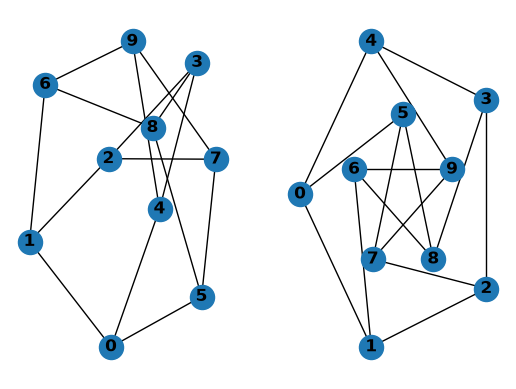

In [113]:
G = nx.petersen_graph()
subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold')
subax2 = plt.subplot(122)
nx.draw_shell(G, nlist=[range(5,10), range(5)], with_labels=True, font_weight='bold')